# Random Forest Regressor — Dự đoán mức lương

**Đồ án:** Hệ hỗ trợ quyết định trong định giá lương và tư vấn đàm phán lương  
**Thành viên phụ trách:** Chí  
**Thuật toán:** Random Forest Regressor  
**Dataset:** 250K Job Salary Prediction Dataset

---

## Mục tiêu notebook

Notebook này thực hiện toàn bộ quy trình huấn luyện và đánh giá mô hình **Random Forest Regressor** để dự đoán mức lương (`salary`) của ứng viên.

Các bước chính:
1. Load dữ liệu đã tiền xử lý từ Preprocessing notebook  
2. Kiểm tra dữ liệu đầu vào  
3. Huấn luyện mô hình với cross-validation  
4. Đánh giá trên tập test  
5. Phân tích Feature Importance  
6. Xây dựng khoảng dự đoán (Prediction Interval)  
7. Lưu model và kết quả  


## 1. Import thư viện

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
import os
import scipy.sparse as sp

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Thư mục lưu ảnh ──────────────────────────────────────────────────────────
FIGURE_DIR = 'figure/RF'
os.makedirs(FIGURE_DIR, exist_ok=True)
DATA_DIR   = 'preprocessing_salary_outputs'

print("Thư viện đã sẵn sàng.")
print(f"Figure dir: {FIGURE_DIR}")
print(f"Data dir  : {DATA_DIR}")


Thư viện đã sẵn sàng.
Figure dir: figure/RF
Data dir  : preprocessing_salary_outputs


## 2. Load dữ liệu đã tiền xử lý

Dữ liệu được load từ thư mục `preprocessing_salary_outputs/` — kết quả xuất ra từ notebook Preprocessing.  
Bao gồm:
- `X_train_processed.npz` / `X_test_processed.npz`: ma trận đặc trưng đã qua chuẩn hóa + One-Hot Encoding  
- `y_train.csv` / `y_test.csv`: biến mục tiêu `salary`  
- `04_processed_feature_names.csv`: tên 48 biến sau tiền xử lý  
- `preprocessor.joblib`: pipeline tiền xử lý (dùng lại khi dự đoán hồ sơ mới)


In [18]:
# ── Load X (sparse matrix từ One-Hot Encoding) ────────────────────────────────
X_train_sp = sp.load_npz(f'{DATA_DIR}/X_train_processed.npz')
X_test_sp  = sp.load_npz(f'{DATA_DIR}/X_test_processed.npz')

# Chuyển sang dense array để Random Forest tương thích hoàn toàn
X_train = X_train_sp.toarray()
X_test  = X_test_sp.toarray()

# ── Load y ────────────────────────────────────────────────────────────────────
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv')['y_train_model_target']
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv')['y_test_model_target']

# ── Load tên biến ─────────────────────────────────────────────────────────────
feature_names_df = pd.read_csv(f'{DATA_DIR}/04_processed_feature_names.csv')
feature_names = feature_names_df['feature_name'].tolist()

# ── Load preprocessor pipeline ───────────────────────────────────────────────
preprocessor = joblib.load(f'{DATA_DIR}/preprocessor.joblib')

# ── Kiểm tra shape ────────────────────────────────────────────────────────────
print("=" * 55)
print(f"X_train shape  : {X_train.shape}")
print(f"X_test  shape  : {X_test.shape}")
print(f"y_train shape  : {y_train.shape}")
print(f"y_test  shape  : {y_test.shape}")
print(f"Số features    : {len(feature_names)}")
print("=" * 55)
print(f"y_train — mean: {y_train.mean():,.0f} | median: {y_train.median():,.0f}")
print(f"y_test  — mean: {y_test.mean():,.0f}  | median: {y_test.median():,.0f}")


X_train shape  : (200000, 48)
X_test  shape  : (50000, 48)
y_train shape  : (200000,)
y_test  shape  : (50000,)
Số features    : 48
y_train — mean: 145,714 | median: 143,430
y_test  — mean: 145,735  | median: 143,540


## 3. Kiểm tra dữ liệu đầu vào

Trước khi huấn luyện, cần xác nhận dữ liệu không có giá trị thiếu và phân phối
của `salary` giữa train/test tương đồng nhau.


Missing in X_train : 0
Missing in X_test  : 0
Missing in y_train : 0
Missing in y_test  : 0


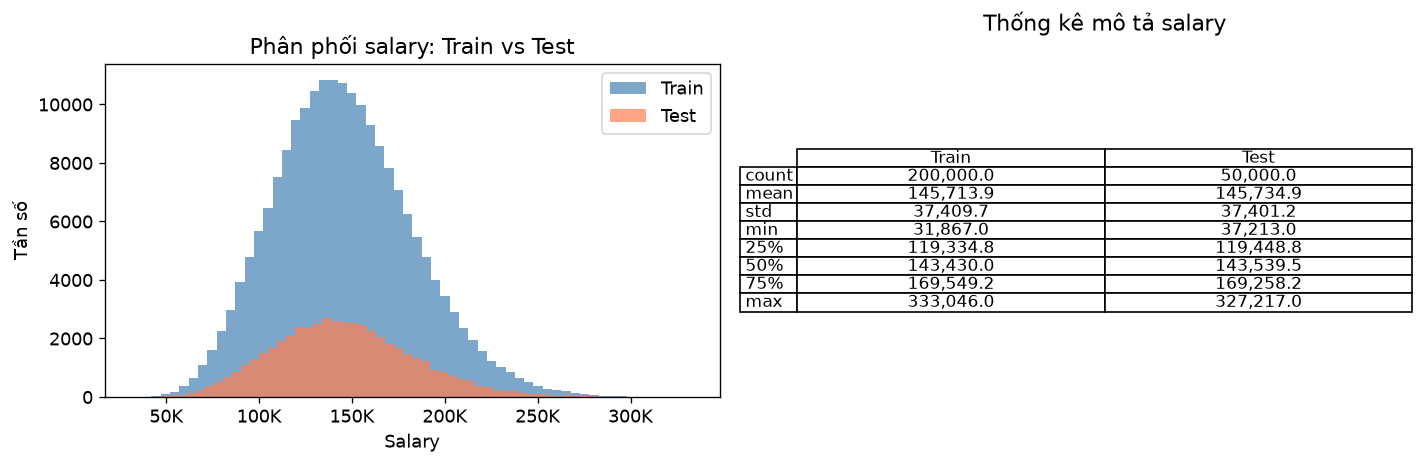

Đã lưu: figure/RF/01_salary_distribution.png


In [19]:
# ── Kiểm tra missing ──────────────────────────────────────────────────────────
print(f"Missing in X_train : {np.isnan(X_train).sum()}")
print(f"Missing in X_test  : {np.isnan(X_test).sum()}")
print(f"Missing in y_train : {y_train.isna().sum()}")
print(f"Missing in y_test  : {y_test.isna().sum()}")

# ── So sánh phân phối y_train vs y_test ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=60, color='steelblue', alpha=0.7, label='Train')
axes[0].hist(y_test,  bins=60, color='coral',     alpha=0.7, label='Test')
axes[0].set_title('Phân phối salary: Train vs Test')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Tần số')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend()

stats = pd.DataFrame({
    'Train': y_train.describe(),
    'Test' : y_test.describe()
})
axes[1].axis('off')
tbl = axes[1].table(
    cellText=[[f'{v:,.1f}' for v in row] for row in stats.values],
    rowLabels=stats.index,
    colLabels=['Train', 'Test'],
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
axes[1].set_title('Thống kê mô tả salary', pad=20)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/01_salary_distribution.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/RF/01_salary_distribution.png")


## 4. Cross-validation với tham số mặc định (Baseline)

Trước khi tinh chỉnh tham số, ta đánh giá mô hình Random Forest với các tham số mặc định
bằng **5-fold Cross-Validation** trên tập train.  

> **Lưu ý quan trọng:** Toàn bộ quá trình cross-validation và tuning chỉ dùng tập **train**.  
> Tập **test** chỉ được sử dụng **một lần duy nhất** ở bước đánh giá cuối.

Metric đánh giá: **RMSE** (Root Mean Squared Error) — phạt nặng các sai số lớn, phù hợp với bài toán dự đoán lương.


  Random Forest — Kết quả Cross-Validation (Baseline)
  CV RMSE  :   6,452.86  ± 17.45
  CV R²    :     0.9702  ± 0.0002


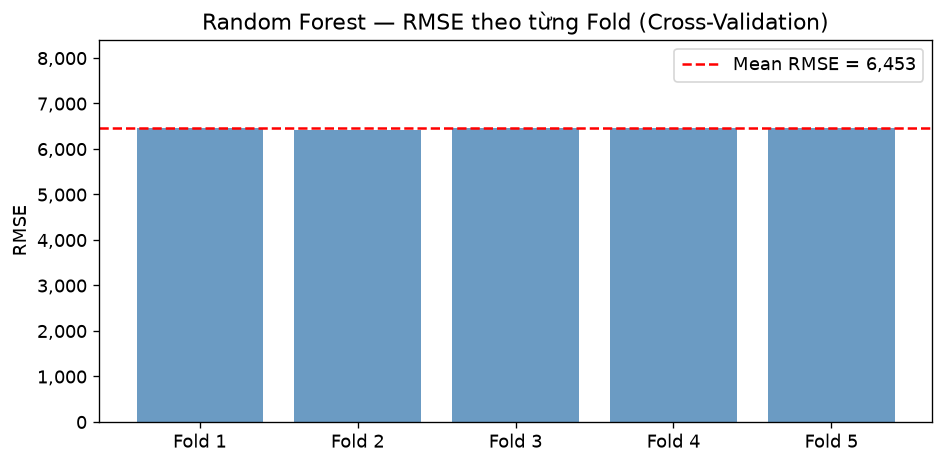

Đã lưu: figure/RF/02_cv_rmse_baseline.png


In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cv_rmse = -cross_val_score(
    rf_baseline, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

cv_r2 = cross_val_score(
    rf_baseline, X_train, y_train,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("=" * 50)
print("  Random Forest — Kết quả Cross-Validation (Baseline)")
print("=" * 50)
print(f"  CV RMSE  : {cv_rmse.mean():>10,.2f}  ± {cv_rmse.std():,.2f}")
print(f"  CV R²    : {cv_r2.mean():>10.4f}  ± {cv_r2.std():.4f}")
print("=" * 50)

# Vẽ kết quả từng fold
fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
ax.bar(folds, cv_rmse, color='steelblue', alpha=0.8)
ax.axhline(cv_rmse.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean RMSE = {cv_rmse.mean():,.0f}')
ax.set_title('Random Forest — RMSE theo từng Fold (Cross-Validation)')
ax.set_ylabel('RMSE')
ax.set_ylim(0, cv_rmse.max() * 1.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_cv_rmse_baseline.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/RF/02_cv_rmse_baseline.png")


## 5. Huấn luyện mô hình Random Forest trên toàn bộ tập train

Sau khi xác nhận kết quả baseline cross-validation, ta huấn luyện mô hình
trên **toàn bộ tập train** với bộ tham số đã chọn.

### Giải thích các tham số chính

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| `n_estimators` | 200 | Số cây quyết định trong rừng |
| `max_depth` | 20 | Độ sâu tối đa mỗi cây — kiểm soát overfitting |
| `min_samples_split` | 5 | Số mẫu tối thiểu để phân chia một nút |
| `min_samples_leaf` | 2 | Số mẫu tối thiểu ở nút lá |
| `max_features` | `'sqrt'` | Số feature ngẫu nhiên xem xét tại mỗi split = √48 ≈ 7 |
| `random_state` | 42 | Đảm bảo tái lập kết quả |
| `n_jobs` | -1 | Dùng toàn bộ CPU để tăng tốc |


In [21]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Đang huấn luyện Random Forest trên toàn bộ tập train...")
rf_model.fit(X_train, y_train)
print("Huấn luyện hoàn thành!")
print(f"  Số cây     : {rf_model.n_estimators}")
print(f"  Số features: {rf_model.n_features_in_}")


Đang huấn luyện Random Forest trên toàn bộ tập train...
Huấn luyện hoàn thành!
  Số cây     : 300
  Số features: 48


## 6. Đánh giá mô hình trên tập test

Tập test được sử dụng **đúng một lần** để có đánh giá khách quan về khả năng
tổng quát hóa của mô hình trên dữ liệu chưa từng thấy.

### Các metric đánh giá

| Metric | Công thức | Ý nghĩa |
|---|---|---|
| **RMSE** | √(Σ(y−ŷ)²/n) | Sai số trung bình bình phương — phạt nặng sai số lớn |
| **MAE** | Σ|y−ŷ|/n | Sai số tuyệt đối trung bình — dễ hiểu, đơn vị = USD |
| **R²** | 1 − SS_res/SS_tot | Tỷ lệ phương sai được giải thích — càng gần 1 càng tốt |
| **MAPE** | Σ|y−ŷ|/y × 100% | Sai số tương đối — trực quan cho bài toán lương |


In [22]:
y_pred_rf = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae  = mean_absolute_error(y_test, y_pred_rf)
r2   = r2_score(y_test, y_pred_rf)
mape = np.mean(np.abs((y_test.values - y_pred_rf) / y_test.values)) * 100

print("=" * 55)
print("  Random Forest — Kết quả trên tập TEST")
print("=" * 55)
print(f"  RMSE : {rmse:>12,.2f}  USD")
print(f"  MAE  : {mae:>12,.2f}  USD")
print(f"  R²   : {r2:>12.4f}")
print(f"  MAPE : {mape:>11.2f}  %")
print("=" * 55)


  Random Forest — Kết quả trên tập TEST
  RMSE :     8,738.17  USD
  MAE  :     6,916.89  USD
  R²   :       0.9454
  MAPE :        5.08  %


### 6.1 Biểu đồ Predicted vs Actual & Residual Plot

- **Predicted vs Actual**: điểm lý tưởng nằm trên đường $y = \hat{y}$  
- **Residual Plot**: phần dư phân tán ngẫu nhiên quanh 0 → mô hình không có bias hệ thống


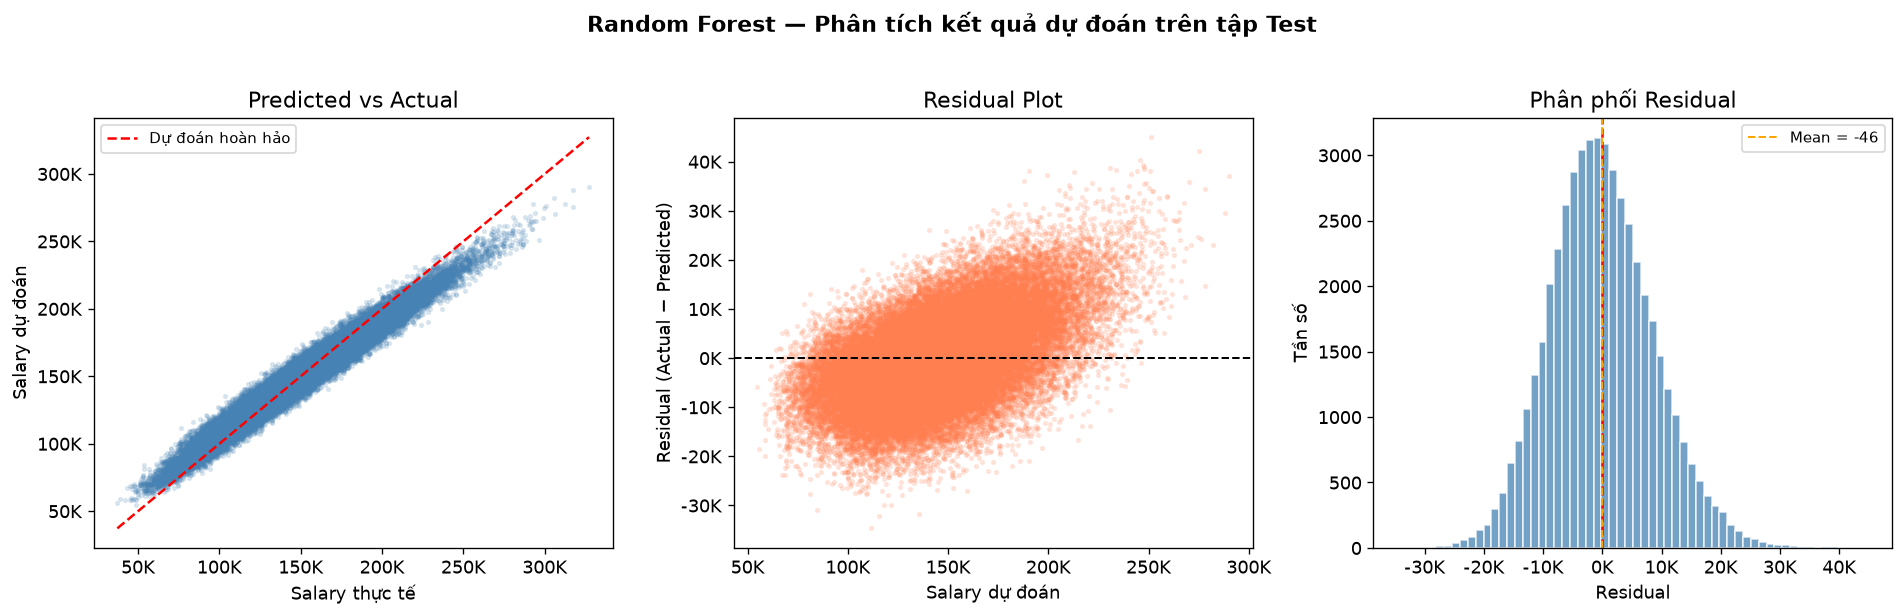

Đã lưu: figure/RF/03_prediction_analysis.png


In [23]:
residuals = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Predicted vs Actual ───────────────────────────────────────────────────────
axes[0].scatter(y_test, y_pred_rf, alpha=0.15, s=5, color='steelblue')
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Dự đoán hoàn hảo')
axes[0].set_xlabel('Salary thực tế')
axes[0].set_ylabel('Salary dự đoán')
axes[0].set_title('Predicted vs Actual')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# ── Residual vs Predicted ─────────────────────────────────────────────────────
axes[1].scatter(y_pred_rf, residuals, alpha=0.15, s=5, color='coral')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Salary dự đoán')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# ── Phân phối Residual ────────────────────────────────────────────────────────
axes[2].hist(residuals, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.2,
                label=f'Mean = {residuals.mean():,.0f}')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Tần số')
axes[2].set_title('Phân phối Residual')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[2].legend(fontsize=9)

plt.suptitle('Random Forest — Phân tích kết quả dự đoán trên tập Test',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/03_prediction_analysis.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/RF/03_prediction_analysis.png")


## 7. Feature Importance — Mức độ quan trọng của từng đặc trưng

Random Forest tính **Mean Decrease in Impurity (MDI)**: trung bình mức độ giảm
impurity (MSE) của mỗi feature khi được dùng làm điểm phân chia trên tất cả các cây.

Feature có MDI cao → ảnh hưởng lớn đến dự đoán lương.


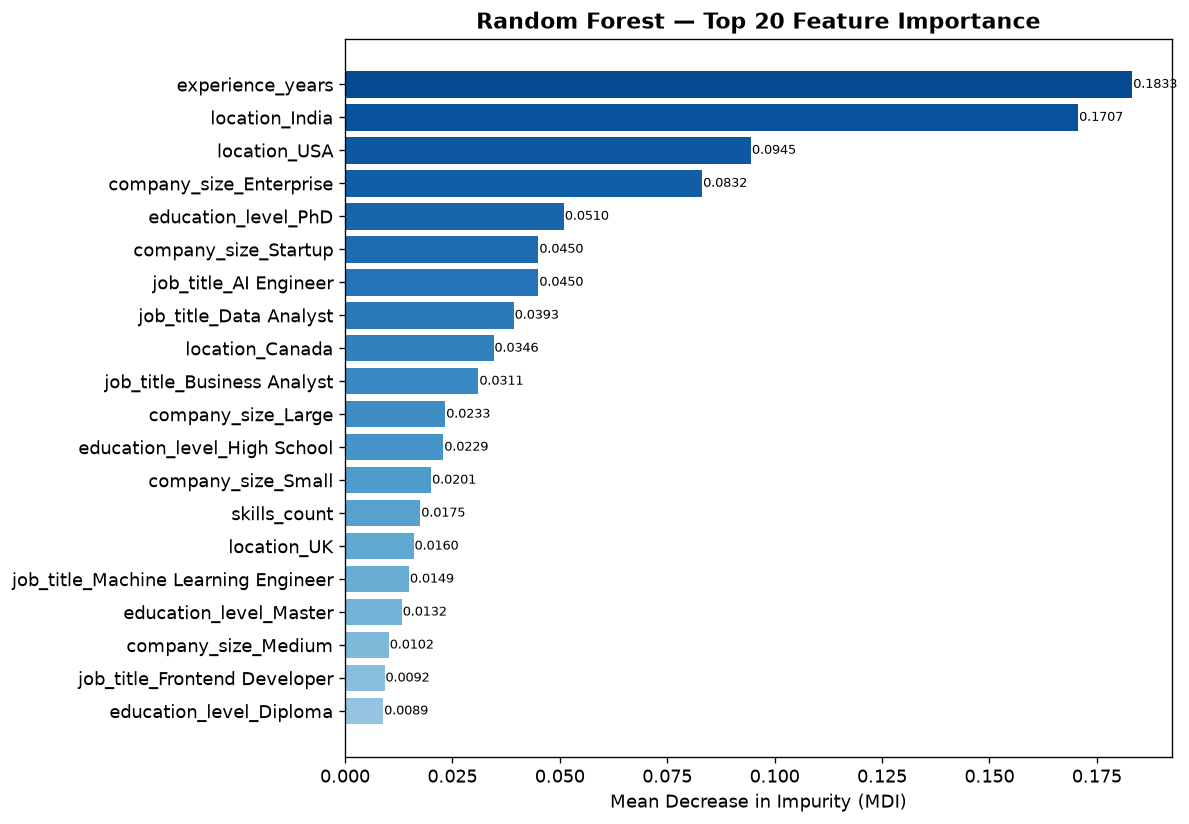

Đã lưu: figure/RF/04_feature_importance.png
 Rank                             Feature  Importance (%)
    1                    experience_years          18.326
    2                      location_India          17.066
    3                        location_USA           9.452
    4             company_size_Enterprise           8.315
    5                 education_level_PhD           5.096
    6                company_size_Startup           4.503
    7               job_title_AI Engineer           4.503
    8              job_title_Data Analyst           3.929
    9                     location_Canada           3.458
   10          job_title_Business Analyst           3.107
   11                  company_size_Large           2.335
   12         education_level_High School           2.290
   13                  company_size_Small           2.007
   14                        skills_count           1.754
   15                         location_UK           1.598
   16 job_title_Machine Lear

In [24]:
fi_series = pd.Series(rf_model.feature_importances_, index=feature_names)
fi_top20  = fi_series.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(fi_top20)))
bars = ax.barh(fi_top20.index, fi_top20.values, color=colors)
ax.set_xlabel('Mean Decrease in Impurity (MDI)')
ax.set_title('Random Forest — Top 20 Feature Importance', fontsize=13, fontweight='bold')

# Gán nhãn giá trị
for bar, val in zip(bars, fi_top20.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/04_feature_importance.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/RF/04_feature_importance.png")

# In bảng top 20
fi_df = fi_series.nlargest(20).reset_index()
fi_df.columns = ['Feature', 'Importance']
fi_df['Rank'] = range(1, 21)
fi_df['Importance (%)'] = (fi_df['Importance'] * 100).round(3)
print(fi_df[['Rank','Feature','Importance (%)']].to_string(index=False))


## 8. Khoảng dự đoán (Prediction Interval)

Trong hệ hỗ trợ quyết định tư vấn lương, ta không chỉ cần **điểm dự đoán** (`ŷ`)
mà còn cần **khoảng dự đoán** để phản ánh độ không chắc chắn.

### Phương pháp: Lấy percentile từ 200 cây

Random Forest gồm 200 cây độc lập. Mỗi cây cho ra một dự đoán khác nhau.
Ta sử dụng phân phối của 200 dự đoán đó để ước lượng khoảng tin cậy:

- **P10** (10th percentile) → mức lương **thấp hợp lý** (floor)
- **Mean** → **mức lương dự đoán trung tâm**
- **P90** (90th percentile) → mức lương **cao — dùng để đàm phán**

Cách tiếp cận này tương đồng với bảng benchmark Q25/median/Q75 đã xây dựng trong EDA.


Đang tính prediction interval từ 200 cây...
Chiều rộng khoảng dự đoán trung bình (P90−P10): 33,211 USD
  P10 trung bình :      129,219 USD
  Mean trung bình:      145,781 USD
  P90 trung bình :      162,429 USD


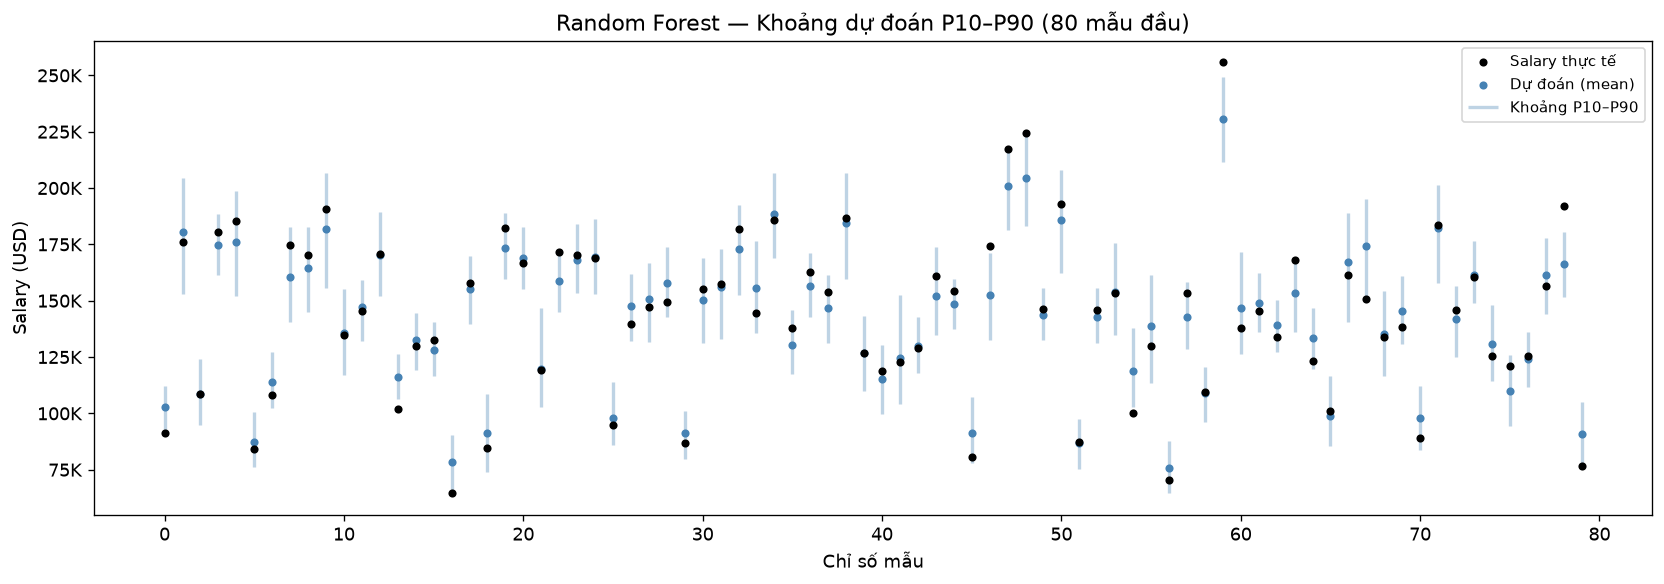

Đã lưu: figure/RF/05_prediction_interval.png


In [25]:
print("Đang tính prediction interval từ 200 cây...")
tree_preds = np.array([tree.predict(X_test) for tree in rf_model.estimators_])
# tree_preds: shape (n_estimators=200, n_test_samples)

y_pred_mean = tree_preds.mean(axis=0)
y_pred_p10  = np.percentile(tree_preds, 10, axis=0)
y_pred_p90  = np.percentile(tree_preds, 90, axis=0)

interval_width = y_pred_p90 - y_pred_p10

print(f"Chiều rộng khoảng dự đoán trung bình (P90−P10): {interval_width.mean():,.0f} USD")
print(f"  P10 trung bình : {y_pred_p10.mean():>12,.0f} USD")
print(f"  Mean trung bình: {y_pred_mean.mean():>12,.0f} USD")
print(f"  P90 trung bình : {y_pred_p90.mean():>12,.0f} USD")

# ── Visualize khoảng dự đoán cho 80 mẫu đầu ─────────────────────────────────
n_show = 80
idx    = np.arange(n_show)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(idx, y_test.values[:n_show], color='black', s=15, zorder=5,
           label='Salary thực tế')
ax.scatter(idx, y_pred_mean[:n_show],  color='steelblue', s=15, zorder=4,
           label='Dự đoán (mean)')
ax.vlines(idx,
          ymin=y_pred_p10[:n_show],
          ymax=y_pred_p90[:n_show],
          color='steelblue', alpha=0.35, linewidth=2,
          label='Khoảng P10–P90')
ax.set_xlabel('Chỉ số mẫu')
ax.set_ylabel('Salary (USD)')
ax.set_title('Random Forest — Khoảng dự đoán P10–P90 (80 mẫu đầu)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/05_prediction_interval.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/RF/05_prediction_interval.png")


### 8.1 Đánh giá chất lượng khoảng dự đoán

**Coverage rate**: tỷ lệ mẫu test có giá trị thực tế nằm trong khoảng [P10, P90].  
Khoảng dự đoán tốt nếu coverage ≈ 80% (vì đây là khoảng 80% CI).


Coverage rate (P10–P90): 92.45%
  Số mẫu trong khoảng : 46,224 / 50,000


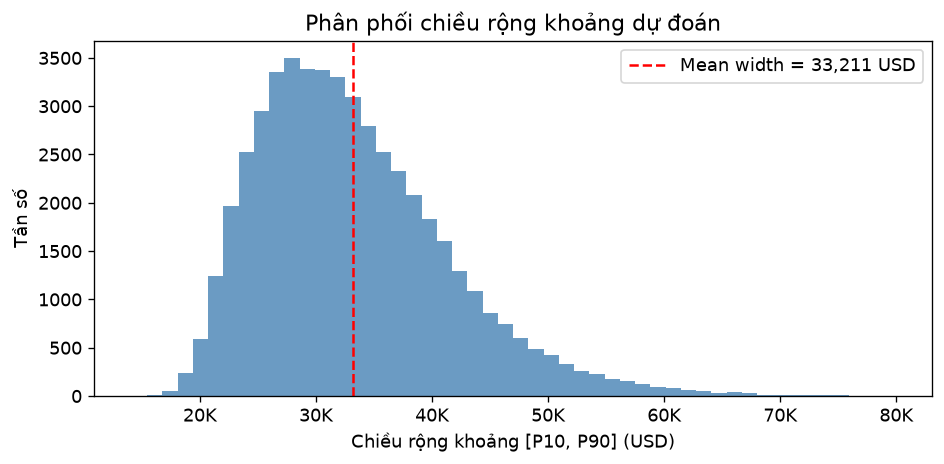

Đã lưu: figure/RF/06_interval_width.png


In [26]:
within = ((y_test.values >= y_pred_p10) & (y_test.values <= y_pred_p90)).sum()
coverage = within / len(y_test) * 100

print(f"Coverage rate (P10–P90): {coverage:.2f}%")
print(f"  Số mẫu trong khoảng : {within:,} / {len(y_test):,}")

# Phân phối chiều rộng khoảng
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(interval_width, bins=50, color='steelblue', alpha=0.8)
ax.axvline(interval_width.mean(), color='red', linestyle='--',
           label=f'Mean width = {interval_width.mean():,.0f} USD')
ax.set_xlabel('Chiều rộng khoảng [P10, P90] (USD)')
ax.set_ylabel('Tần số')
ax.set_title('Phân phối chiều rộng khoảng dự đoán')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/06_interval_width.png', bbox_inches='tight')
plt.show()
print("Đã lưu: figure/RF/06_interval_width.png")


## 9. Ví dụ dự đoán cho hồ sơ mới (demo hệ thống)

Minh họa cách hệ thống sử dụng mô hình để tư vấn lương cho một hồ sơ ứng viên cụ thể.


In [27]:
def predict_salary(profile: dict, preprocessor, model, tree_preds_func=False):
    """
    Dự đoán mức lương cho một hồ sơ ứng viên mới.

    Parameters
    ----------
    profile : dict — thông tin ứng viên (raw, chưa xử lý)
    preprocessor : Pipeline — pipeline đã fit từ Preprocessing notebook
    model : RandomForestRegressor — mô hình đã huấn luyện

    Returns
    -------
    dict — {'point': float, 'low_p10': float, 'high_p90': float}
    """
    df_new   = pd.DataFrame([profile])
    X_new    = preprocessor.transform(df_new)
    if hasattr(X_new, 'toarray'):
        X_new = X_new.toarray()

    # Point prediction
    y_point  = model.predict(X_new)[0]

    # Interval từ từng cây
    preds_trees = np.array([t.predict(X_new)[0] for t in model.estimators_])
    y_low  = np.percentile(preds_trees, 10)
    y_high = np.percentile(preds_trees, 90)

    return {'point': y_point, 'low_p10': y_low, 'high_p90': y_high}


# ── Hồ sơ mẫu ────────────────────────────────────────────────────────────────
sample_profile = {
    'job_title'       : 'Data Scientist',
    'experience_years': 5,
    'education_level' : 'Master',
    'skills_count'    : 8,
    'industry'        : 'Technology',
    'company_size'    : 'Large',
    'location'        : 'USA',
    'remote_work'     : 'Hybrid',
    'certifications'  : 3
}

result = predict_salary(sample_profile, preprocessor, rf_model)

print("=" * 55)
print("  Kết quả tư vấn lương (Random Forest)")
print("=" * 55)
print(f"  Hồ sơ     : {sample_profile['job_title']}, "
      f"{sample_profile['experience_years']} năm KN, {sample_profile['education_level']}")
print(f"  Địa điểm  : {sample_profile['location']} | "
      f"Công ty   : {sample_profile['company_size']}")
print("-" * 55)
print(f"  Mức thấp hợp lý (P10) : $ {result['low_p10']:>10,.0f}")
print(f"  Mức dự đoán trung tâm : $ {result['point']:>10,.0f}")
print(f"  Mức đàm phán (P90)    : $ {result['high_p90']:>10,.0f}")
print("=" * 55)


  Kết quả tư vấn lương (Random Forest)
  Hồ sơ     : Data Scientist, 5 năm KN, Master
  Địa điểm  : USA | Công ty   : Large
-------------------------------------------------------
  Mức thấp hợp lý (P10) : $    156,166
  Mức dự đoán trung tâm : $    178,894
  Mức đàm phán (P90)    : $    194,665


## 10. Lưu model và kết quả

Lưu model để sử dụng trong các bước tiếp theo:
- So sánh với các mô hình khác (notebook tổng hợp)  
- Tích hợp vào giao diện hệ thống tư vấn lương


In [28]:
# ── Lưu model ────────────────────────────────────────────────────────────────
joblib.dump(rf_model, 'model_rf.joblib')
print("Đã lưu: model_rf.joblib")

# ── Lưu kết quả dự đoán ──────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'y_actual'   : y_test.values,
    'y_pred'     : y_pred_mean,
    'y_pred_p10' : y_pred_p10,
    'y_pred_p90' : y_pred_p90,
    'residual'   : y_test.values - y_pred_mean
})
results_df.to_csv('rf_predictions.csv', index=False)
print("Đã lưu: rf_predictions.csv")

# ── Lưu metrics ──────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'model': 'Random Forest',
    'RMSE' : round(rmse, 2),
    'MAE'  : round(mae,  2),
    'R2'   : round(r2,   4),
    'MAPE' : round(mape, 2)
}])
metrics_df.to_csv('rf_metrics.csv', index=False)
print("Đã lưu: rf_metrics.csv")

print()
print("=" * 55)
print("  Tóm tắt kết quả Random Forest Regressor")
print("=" * 55)
print(f"  RMSE  : {rmse:>12,.2f} USD")
print(f"  MAE   : {mae:>12,.2f} USD")
print(f"  R²    : {r2:>12.4f}")
print(f"  MAPE  : {mape:>11.2f} %")
print(f"  Coverage P10–P90 : {coverage:.2f}%")
print("=" * 55)


Đã lưu: model_rf.joblib
Đã lưu: rf_predictions.csv
Đã lưu: rf_metrics.csv

  Tóm tắt kết quả Random Forest Regressor
  RMSE  :     8,738.17 USD
  MAE   :     6,916.89 USD
  R²    :       0.9454
  MAPE  :        5.08 %
  Coverage P10–P90 : 92.45%
